In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

listing = pd.read_csv("/Users/seanshih/Desktop/IDX/CRMLSListed_All.csv")


/var/folders/5h/bxf_bvns78z4pt8s0drk3kcc0000gn/T/ipykernel_18697/2338962053.py:5: DtypeWarning: Columns (2,82) have mixed types. Specify dtype option on import or set low_memory=False.
  listing = pd.read_csv("/Users/seanshih/Desktop/IDX/CRMLSListed_All.csv")


In [31]:
print(listing.columns)

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'StreetNumberNumeric', 'LivingArea.1', 'ListingId',
       'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTot

In [34]:
listing.shape

(852963, 84)

In [36]:
listing.dtypes

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
                                 ...   
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1                object
BuyerAgencyCompensationType      object
BuyerAgencyCompensation         float64
Length: 84, dtype: object

In [38]:
#WEEK 1 STUFF
#filer to residential
print(listing["PropertyType"].value_counts())

# Filter to residential only
listing = listing[listing["PropertyType"] == "Residential"]
print(f"\nFiltered to {len(listing):,} residential records")

PropertyType
Residential            540183
ResidentialLease       178041
Land                    56372
ResidentialIncome       31650
ManufacturedInPark      24531
CommercialSale          11715
CommercialLease          7736
BusinessOpportunity      2735
Name: count, dtype: int64

Filtered to 540,183 residential records


In [40]:
#WEEK 2-3 EDA ANALYSIS
missing = listing.isnull().sum()
missing_pct = (missing / len(listing) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)


In [44]:
missing_df

,missing_count,missing_pct
TaxAnnualAmount,540183,100.0
FireplacesTotal,540183,100.0
ElementarySchoolDistrict,540183,100.0
BusinessType,540183,100.0
TaxYear,540183,100.0
...,...,...
ParkingTotal,20,0.0
ListingKey,0,0.0
ListingId,0,0.0
ListPrice.1,0,0.0


In [48]:
#from the new dataframe, find any columns with greater missing % than 90%
cols_to_drop = missing_df[missing_df["missing_pct"] > 90].index.tolist()

print(f"Columns with >90% missing ({len(cols_to_drop)}):\n")
for col in cols_to_drop:
    print(f"  {col:40s} {missing_df.loc[col, 'missing_pct']}%")

Columns with >90% missing (13):

  TaxAnnualAmount                          100.0%
  FireplacesTotal                          100.0%
  ElementarySchoolDistrict                 100.0%
  BusinessType                             100.0%
  TaxYear                                  100.0%
  CoveredSpaces                            100.0%
  MiddleOrJuniorSchoolDistrict             100.0%
  AboveGradeFinishedArea                   100.0%
  BelowGradeFinishedArea                   99.44%
  CoBuyerAgentFirstName                    97.33%
  BuilderName                              95.33%
  LotSizeDimensions                        94.79%
  BuildingAreaTotal                        91.11%


In [50]:
high_missing = missing_df[missing_df["missing_pct"] > 90]
print(f"Total columns >90% missing: {len(high_missing)}")
print(high_missing)

Total columns >90% missing: 13
                              missing_count  missing_pct
TaxAnnualAmount                      540183       100.00
FireplacesTotal                      540183       100.00
ElementarySchoolDistrict             540183       100.00
BusinessType                         540183       100.00
TaxYear                              540183       100.00
CoveredSpaces                        540183       100.00
MiddleOrJuniorSchoolDistrict         540183       100.00
AboveGradeFinishedArea               540183       100.00
BelowGradeFinishedArea               537154        99.44
CoBuyerAgentFirstName                525755        97.33
BuilderName                          514943        95.33
LotSizeDimensions                    512056        94.79
BuildingAreaTotal                    492186        91.11


In [52]:
listing = listing.drop(columns=cols_to_drop)
#drop the columns with missing % greater than 90%
#dropped 13 columns 

In [54]:
listing.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName',
       'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1', 'StreetNumberNumeric',
       'LivingArea.1', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'Longitude.1',
       'PurchaseContractDate', 'ListingContractDate',

In [58]:
market_fields = ["ListPrice", "OriginalListPrice", "LivingArea",
                 "LotSizeAcres", "LotSizeSquareFeet", "LotSizeArea",
                 "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket",
                 "YearBuilt", "Stories", "Levels", "GarageSpaces", "ParkingTotal",
                 "AssociationFee", "AssociationFeeFrequency", "FireplaceYN",
                 "AttachedGarageYN", "NewConstructionYN", "MainLevelBedrooms",
                 "City", "CountyOrParish", "PostalCode", "StateOrProvince",
                 "PropertyType", "PropertySubType", "UnparsedAddress",
                 "Latitude", "Longitude", "ListingContractDate", "MlsStatus"]

market_found = [c for c in market_fields if c in listing.columns]
metadata_found = [c for c in listing.columns if c not in market_found]

print(f"MARKET ANALYSIS FIELDS ({len(market_found)}):")
print(market_found)

print(f"\nMETADATA FIELDS ({len(metadata_found)}):")
print(metadata_found)

MARKET ANALYSIS FIELDS (31):
['ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres', 'LotSizeSquareFeet', 'LotSizeArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt', 'Stories', 'Levels', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'AssociationFeeFrequency', 'FireplaceYN', 'AttachedGarageYN', 'NewConstructionYN', 'MainLevelBedrooms', 'City', 'CountyOrParish', 'PostalCode', 'StateOrProvince', 'PropertyType', 'PropertySubType', 'UnparsedAddress', 'Latitude', 'Longitude', 'ListingContractDate', 'MlsStatus']

METADATA FIELDS (40):
['ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'ListingKeyNumeric', 'MLSAreaMajor', 'PropertyType.1', 'ElementarySchool', 'ListAgentFirstName.1', 'SubdivisionName', 'BuyerOfficeAOR',

In [62]:
numeric_cols = ["ListPrice", "OriginalListPrice", "LivingArea",
                "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
                "DaysOnMarket", "YearBuilt"]

listing[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,5.401830e+05,5.394090e+05,5.396270e+05,4.956650e+05,540035.000000,540128.000000,540183.000000,539244.000000
mean,1.312997e+06,1.397125e+06,1.980059e+03,6.523781e+01,3.222963,2.626022,19.539904,1979.604852
std,2.346687e+06,7.357159e+06,2.338269e+04,1.213681e+04,1.186992,3.258017,26.771154,26.994381
min,1.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-58.000000,1776.000000
1%,2.100000e+05,2.000000e+05,5.880000e+02,0.000000e+00,1.000000,1.000000,0.000000,1911.000000
5%,3.450000e+05,3.460000e+05,8.160000e+02,2.880000e-02,2.000000,1.000000,0.000000,1929.000000
25%,5.800000e+05,5.850000e+05,1.247000e+03,1.200000e-01,2.000000,2.000000,5.000000,1961.000000
50%,8.400000e+05,8.490000e+05,1.669000e+03,1.700000e-01,3.000000,2.000000,11.000000,1980.000000
75%,1.375000e+06,1.389000e+06,2.300000e+03,3.140000e-01,4.000000,3.000000,23.000000,2001.000000
95%,3.450000e+06,3.495000e+06,3.868000e+03,3.573500e+00,5.000000,5.000000,71.000000,2023.000000


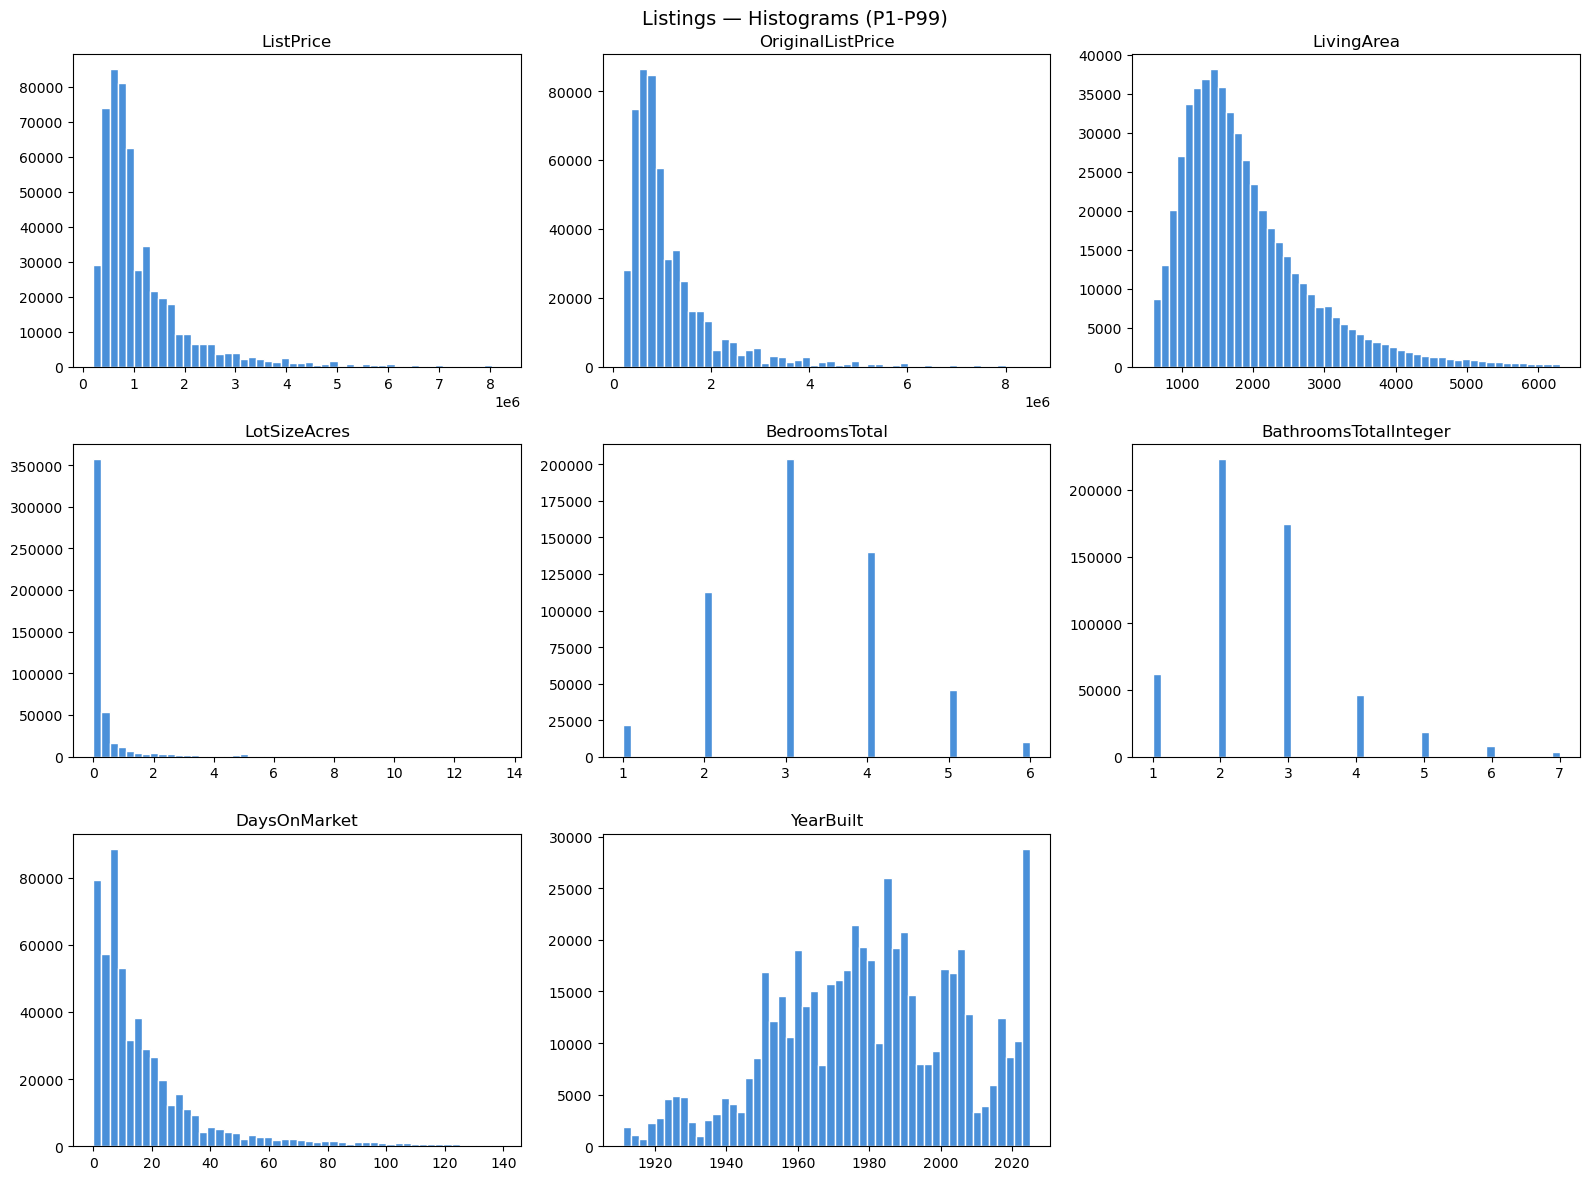

In [64]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = listing[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    clipped = data[(data >= lo) & (data <= hi)]
    
    axes[i].hist(clipped, bins=50, edgecolor="white", color="#4a90d9")
    axes[i].set_title(col)

if len(numeric_cols) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle("Listings — Histograms (P1-P99)", fontsize=14)
plt.tight_layout()
plt.show()

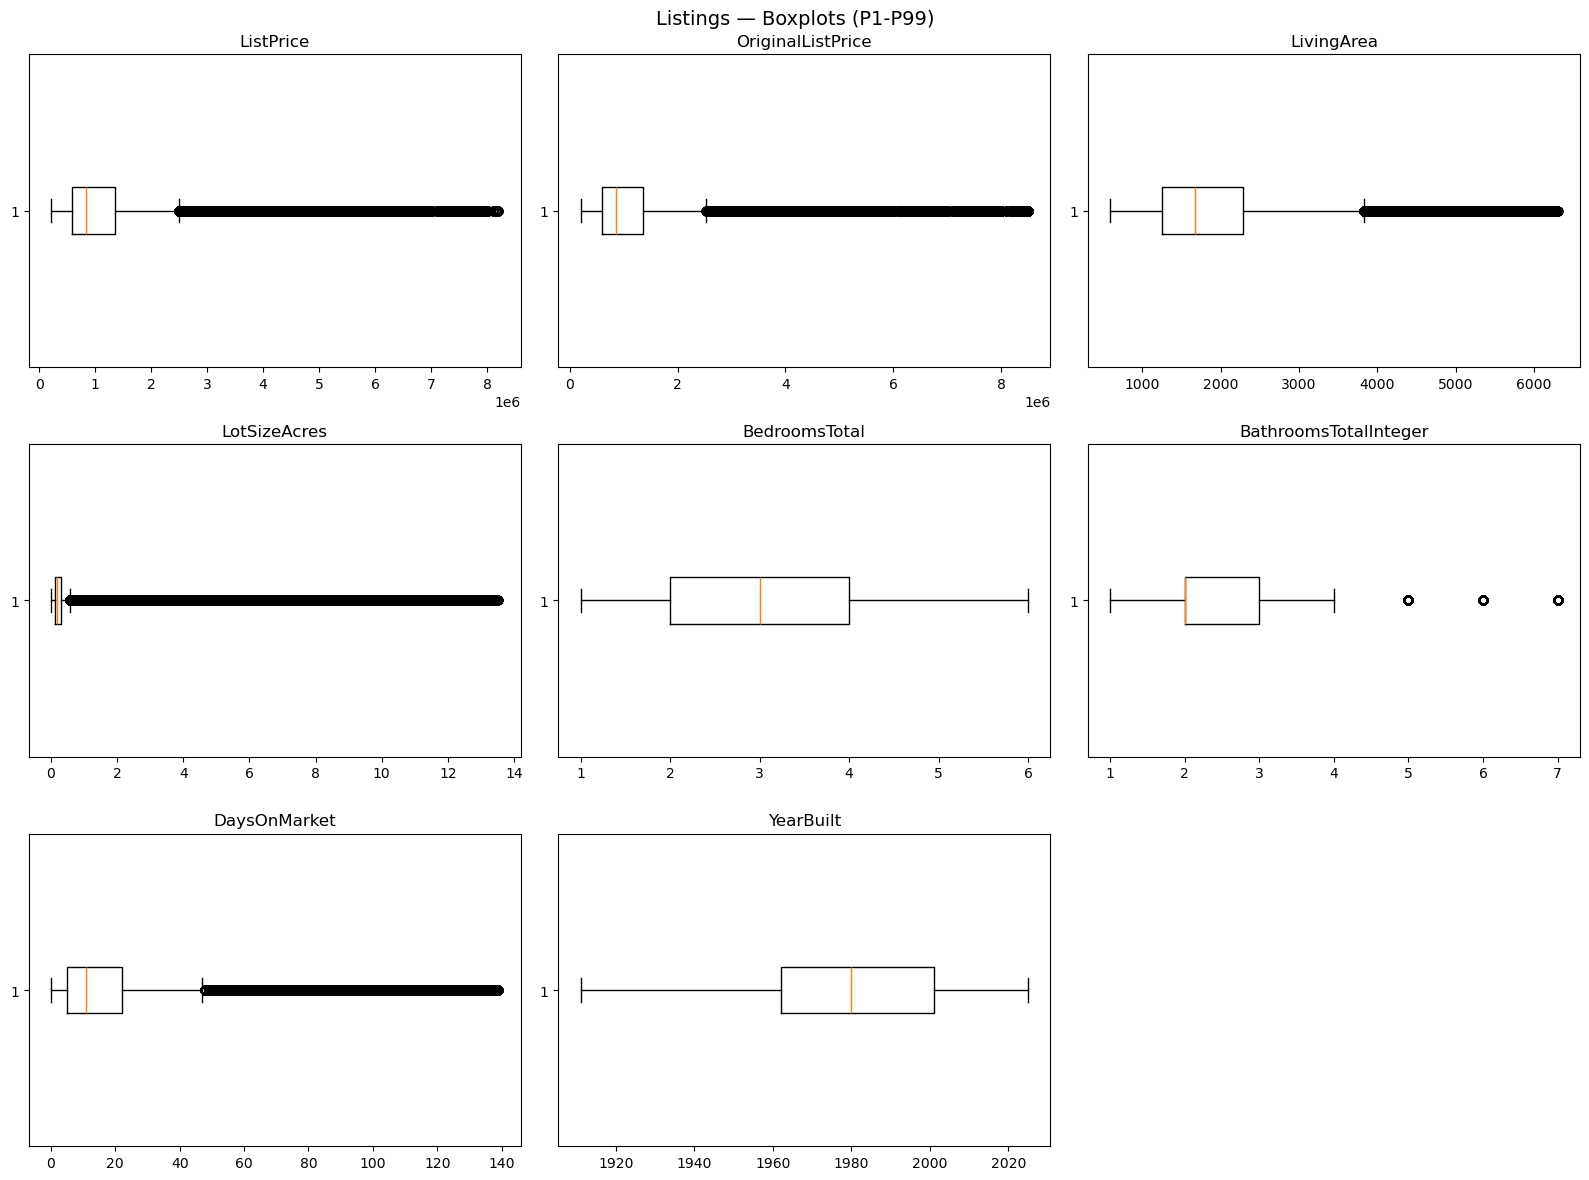

In [66]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = listing[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    clipped = data[(data >= lo) & (data <= hi)]
    
    axes[i].boxplot(clipped, vert=False)
    axes[i].set_title(col)

if len(numeric_cols) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle("Listings — Boxplots (P1-P99)", fontsize=14)
plt.tight_layout()
plt.show()

In [70]:
print("EXTREME OUTLIERS (below P1 or above P99):\n")
for col in numeric_cols:
    data = listing[col].dropna()
    p01, p99 = data.quantile(0.01), data.quantile(0.99)
    outliers = data[(data < p01) | (data > p99)]
    print(f"{col:30s} {len(outliers):>6,} outliers")

EXTREME OUTLIERS (below P1 or above P99):

ListPrice                      10,659 outliers
OriginalListPrice              10,650 outliers
LivingArea                     10,749 outliers
LotSizeAcres                    4,957 outliers
BedroomsTotal                   6,512 outliers
BathroomsTotalInteger           4,353 outliers
DaysOnMarket                    5,347 outliers
YearBuilt                       7,544 outliers


In [74]:
listing.to_csv("/Users/seanshih/Desktop/CRMLS_Listing_Residential.csv", index=False)

In [80]:
#FRED WEEK 2-3

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])
mortgage.columns = ['date', 'rate_30yr_fixed']

In [82]:
mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage_monthly = (
mortgage.groupby('year_month')['rate_30yr_fixed']
.mean().reset_index()
)

In [86]:
# Listings dataset — key off ListingContractDate
listing['year_month'] = pd.to_datetime(
listing['ListingContractDate']).dt.to_period('M')

In [88]:
listings_with_rates = listing.merge(mortgage_monthly, on='year_month', how='left')

In [90]:
print(listings_with_rates['rate_30yr_fixed'].isnull().sum())

0


In [ ]:
listings_with_rates.to_csv("/Users/seanshih/Desktop/IDX/CRMLS_Listed_Enriched.csv", index=False)